<h1 align='center' style='color:purple'>Clustering With K Means - Python Tutorial</h1>

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt

In [2]:
iris = load_iris()


In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
df = df[['petal length (cm)', 'petal width (cm)']]

print(df.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


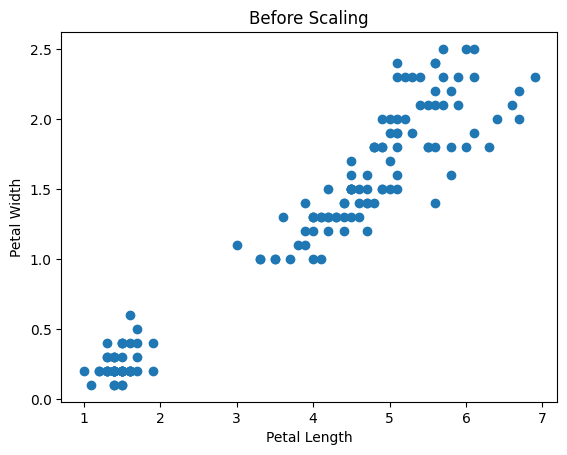

In [5]:
plt.scatter(df['petal length (cm)'],
            df['petal width (cm)'])

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.title('Before Scaling')

plt.show()

In [6]:
scaler = MinMaxScaler()

In [7]:
df['petal length (cm)'] = scaler.fit_transform(
    df[['petal length (cm)']]
)

<h4 style='color:purple'>Preprocessing using min max scaler</h4>

In [8]:
df['petal width (cm)'] = scaler.fit_transform(
    df[['petal width (cm)']]
)

In [9]:
print(df.head())

   petal length (cm)  petal width (cm)
0           0.067797          0.041667
1           0.067797          0.041667
2           0.050847          0.041667
3           0.084746          0.041667
4           0.067797          0.041667


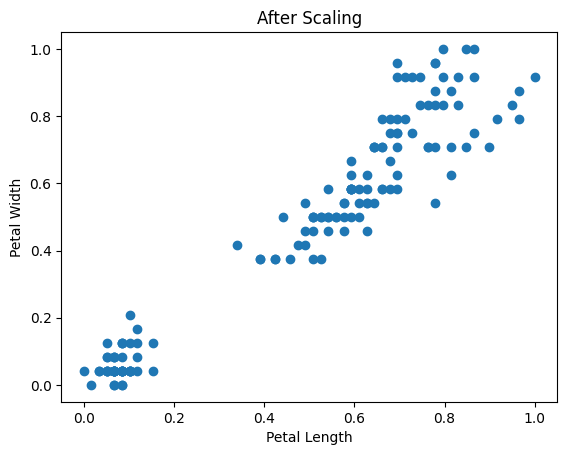

In [10]:
plt.scatter(df['petal length (cm)'],
            df['petal width (cm)'])

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.title('After Scaling')

plt.show()

In [11]:
km = KMeans(n_clusters=3)

In [12]:
y_predicted = km.fit_predict(df)

print(y_predicted)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [13]:
df['cluster'] = y_predicted

print(df.head())

   petal length (cm)  petal width (cm)  cluster
0           0.067797          0.041667        1
1           0.067797          0.041667        1
2           0.050847          0.041667        1
3           0.084746          0.041667        1
4           0.067797          0.041667        1


In [14]:
print(km.cluster_centers_)

[[0.7740113  0.81510417]
 [0.07830508 0.06083333]
 [0.55867014 0.51041667]]


<h4 style='color:purple'>Elbow Plot</h4>

In [15]:
  df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

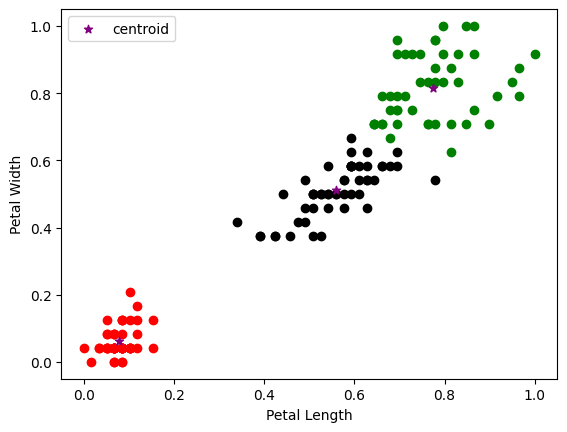

In [16]:
plt.scatter(df1['petal length (cm)'],
            df1['petal width (cm)'],
            color='green')

plt.scatter(df2['petal length (cm)'],
            df2['petal width (cm)'],
            color='red')

plt.scatter(df3['petal length (cm)'],
            df3['petal width (cm)'],
            color='black')

plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            color='purple',
            marker='*',
            label='centroid')

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.legend()

plt.show()

In [17]:
sse = []

In [18]:
k_rng = range(1,10)

In [19]:
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['petal length (cm)',
               'petal width (cm)']])

    sse.append(km.inertia_)

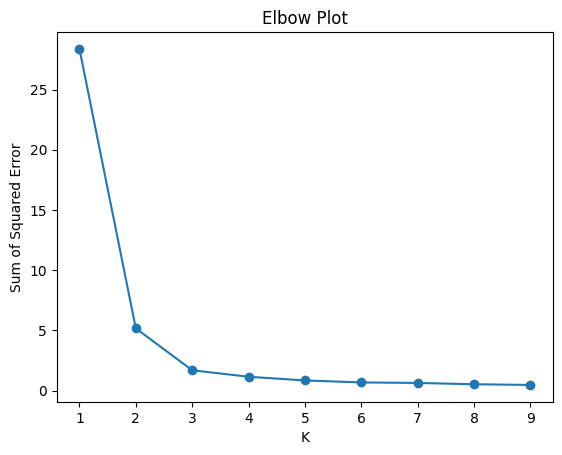

In [20]:
plt.plot(k_rng, sse, marker='o')

plt.xlabel('K')
plt.ylabel('Sum of Squared Error')

plt.title('Elbow Plot')

plt.show()